# Deliverable 2: Ciprofloxacin reaction model (v1, Dodd constants)
**Lead:** Partner A · **Shared files:** `ris/chlorine_backbone.py` (chlorine) and `ris/cipro_model.py` (cipro). This notebook runs them and explains the results; it holds no constants itself.

**What changed (Oct 5):** almost every cipro constant now comes from **Dodd et al. 2005** (Environ. Sci. Technol. 39:7065, doi 10.1021/es050054e). Three things in that paper changed the model:
1. **All products keep the quinolone core.** N-chloro-cipro (Dodd calls it CF-Ia1) breaks apart into CF-Pa1 with about 100% yield, and later products (CF-Pa2, CF-Pa3) keep the core too. So the old `f_core` and "fully degraded" group are gone. The model now tracks **P1** (CF-Pa1) and **P2** (later products, lumped). Whether they still stop bacteria is the activity model's job.
2. **The breakdown speed depends on pH:** 2.4 × 10⁻⁴ s⁻¹ at pH 4.6 up to 7.6 × 10⁻⁴ s⁻¹ at pH 8.6.
3. **Dodd already suggested that sulfite/thiosulfate dechlorination could regenerate cipro at plants (p. 7073), but gave no rate.** So Gap 2 is "proposed in 2005, still unmeasured," not a brand-new idea. Say it that way to judges.

**Reactions** (state: FC, TA, MCA, CT, CIP, NCL, P1, P2)
1. Chlorine backbone (imported)
2. cipro + HOCl → N-chloro-cipro (speciation-weighted, Dodd Table 3)
3. cipro + combined chlorine → N-chloro-cipro (Dodd p. 7074)
4. N-chloro-cipro → P1 (pH-dependent, Dodd p. 7071)
5. P1 + HOCl → P2 (rough estimate from Dodd Fig. 3)
6. After bisulfite: N-chloro-cipro → cipro (`k_rev_bisulfite`, unknown, Gap 2) or keeps breaking apart

**To change a constant:** edit `ris/cipro_model.py`, then re-run.

In [1]:
# Load tools + the model code from this repo (run from the repo root or notebooks/)
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "ris").exists():
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ris import chlorine_backbone as cb
from ris import cipro_model as cm
print("Loaded.")

Loaded.


## Step 2: The constants in use (and how sure we are)
`low`/`high` are the ranges used in the sensitivity test (from Dodd's standard errors, Jasper 2016, or stated assumptions).

In [2]:
rows = [(k, v, *cm.RANGES.get(k, ("", ""))) for k, v in cm.CIPRO.items()]
pd.DataFrame(rows, columns=["constant", "value", "low", "high"])

,constant,value,low,high
0,pKa1,6.200000e+00,,
1,pKa2,8.800000e+00,,
2,k_HOCl_cation,4.300000e+03,430.0,11000.0
3,k_HOCl_neutral,3.800000e+05,140000.0,620000.0
4,k_HOCl_anion,4.900000e+07,30000000.0,68000000.0
5,k_frag_neutral,2.400000e-04,0.00017,0.00031
6,k_frag_anion,7.600000e-04,0.00056,0.0009
7,pKa_int,6.200000e+00,5.5,7.0
8,k_CC_cipro,2.900000e+01,15.0,60.0
9,k_P1_HOCl,1.300000e+01,3.0,50.0


## Step 3: Knobs

In [3]:
pH          = 7.5
Cl_dose_mgL = 5.0      # mg/L as Cl2
NH3_mgN_L   = 0.0      # mg/L as N. 0 = free chlorine (like San José's nitrified effluent)
cipro_mgL   = 1.0      # lab-level starting cipro
contact_min = 30       # chlorine contact time before bisulfite
after_bisulfite_min = 5

## Step 4: Run one experiment
`run_batch()` is the single function the flow model, baseline and optimizer will all call.

In [4]:
res, sol = cm.run_batch(pH, Cl_dose_mgL, NH3_mgN_L, cipro_mgL, contact_min, after_bisulfite_min)
print(f"cipro + HOCl effective rate at pH {pH}: {cm.k_HOCl_eff(pH):.2e} M^-1 s^-1  -> cipro is gone in well under a second")
print(f"N-chloro-cipro breakdown at pH {pH}: {cm.k_frag(pH):.2e} s^-1  (half-life {np.log(2)/cm.k_frag(pH)/60:.0f} min)\n")
for k, v in res.items():
    print(f"{k:24s} {v:9.2f}")

cipro + HOCl effective rate at pH 7.5: 2.58e+06 M^-1 s^-1  -> cipro is gone in well under a second
N-chloro-cipro breakdown at pH 7.5: 7.35e-04 s^-1  (half-life 16 min)

FC_end_mgL                    3.30
CC_end_mgL                    0.00
CT                          120.02
cipro_end_ugL                 0.00
NCL_end_ugL                 266.25
cipro_thiosulfate_ugL       266.25
cipro_out_ugL                 0.00
NCL_out_ugL                 213.55
P1_out_ugL                  554.89
P2_out_ugL                  231.55
drug_only_removal_pct       100.00
core_remaining_pct          100.00


**How to read this**
- `cipro_out_ugL`: real cipro leaving the plant (after bisulfite). With `k_rev_bisulfite = 0` it's zero.
- `cipro_thiosulfate_ugL`: what a lab would *report* as cipro if it quenched with thiosulfate at the end of contact (cipro + N-chloro-cipro). Published data (Dodd, Jasper, probably Kennedy Neth) were measured this way, so compare them to this number.
- `NCL_out_ugL`: N-chloro-cipro still intact when the water leaves. This is the amount that **could turn back into cipro** if bisulfite reverses it.
- `drug_only_removal_pct` vs `core_remaining_pct`: the gap between "the drug is gone" and "molecules with the antibacterial core are still there."

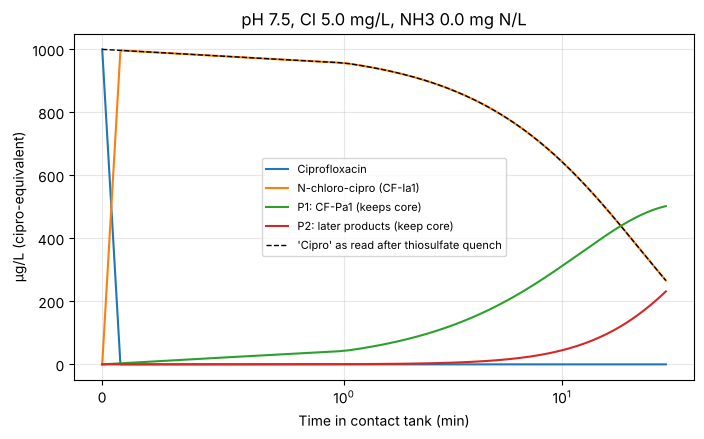

In [5]:
tm = sol.t / 60
plt.figure(figsize=(8, 4.5))
for i, lab in [(4, "Ciprofloxacin"), (5, "N-chloro-cipro (CF-Ia1)"), (6, "P1: CF-Pa1 (keeps core)"), (7, "P2: later products (keep core)")]:
    plt.plot(tm, cm.M_to_ugL(sol.y[i]), label=lab)
plt.plot(tm, cm.M_to_ugL(sol.y[4] + sol.y[5]), "k--", lw=1, label="'Cipro' as read after thiosulfate quench")
plt.xlabel("Time in contact tank (min)"); plt.ylabel("µg/L (cipro-equivalent)")
plt.title(f"pH {pH}, Cl {Cl_dose_mgL} mg/L, NH3 {NH3_mgN_L} mg N/L"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.xscale("symlog", linthresh=1); plt.show()

In [6]:
# Checks: nothing negative; cipro mass conserved across all its forms
assert np.all(sol.y >= -1e-14), "negative concentration"
assert np.allclose(sol.y[4:8].sum(axis=0), sol.y[4, 0], rtol=1e-6), "cipro mass not conserved"
print("Checks passed: no negatives, cipro mass conserved.")

Checks passed: no negatives, cipro mass conserved.


## Step 5: Sensitivity test: which constants actually matter?
Each constant is set to its low and then its high value while everything else stays the same. The table shows how much each output changes (µg/L). **Big numbers = worth measuring; zeros = don't waste time on it.**

In [7]:
outs = ["cipro_thiosulfate_ugL", "cipro_out_ugL", "NCL_out_ugL", "P1_out_ugL", "P2_out_ugL"]
base, _ = cm.run_batch(pH, Cl_dose_mgL, NH3_mgN_L, cipro_mgL, contact_min, after_bisulfite_min)
rows = []
for k, (lo, hi) in cm.RANGES.items():
    for tag, v in [("low", lo), ("high", hi)]:
        p = dict(cm.CIPRO); p[k] = v
        r, _ = cm.run_batch(pH, Cl_dose_mgL, NH3_mgN_L, cipro_mgL, contact_min, after_bisulfite_min, p=p)
        rows.append([k, tag, v] + [round(r[o] - base[o], 1) for o in outs])
sens = pd.DataFrame(rows, columns=["constant", "setting", "value"] + ["Δ " + o for o in outs])
sens

,constant,setting,value,Δ cipro_thiosulfate_ugL,Δ cipro_out_ugL,Δ NCL_out_ugL,Δ P1_out_ugL,Δ P2_out_ugL
0,k_HOCl_cation,low,4.300000e+02,0.0,0.0,0.0,0.0,-0.0
1,k_HOCl_cation,high,1.100000e+04,-0.0,0.0,-0.0,-0.0,0.0
2,k_HOCl_neutral,low,1.400000e+05,0.0,0.0,0.0,0.0,-0.0
3,k_HOCl_neutral,high,6.200000e+05,-0.0,0.0,-0.0,-0.0,0.0
4,k_HOCl_anion,low,3.000000e+07,0.0,0.0,0.0,0.0,-0.0
5,k_HOCl_anion,high,6.800000e+07,-0.0,0.0,-0.0,-0.0,0.0
6,k_frag_neutral,low,1.700000e-04,1.6,0.0,1.5,-0.8,-0.7
7,k_frag_neutral,high,3.100000e-04,-1.6,0.0,-1.5,0.8,0.7
8,k_frag_anion,low,5.600000e-04,108.9,0.0,105.0,-62.6,-42.4
9,k_frag_anion,high,9.000000e-04,-56.8,0.0,-52.1,27.3,24.8


### What the sensitivity test says (pH 7.5, 5 mg/L chlorine, 30 min)
- **The three cipro + HOCl constants don't matter at all.** Cipro reacts in a fraction of a second whether they're low or high. Good answer for a judge asking about their large error bars.
- **Combined-chlorine speed (`k_CC_cipro`) doesn't matter here either.** Even with ammonia present, cipro grabs free chlorine before the chlorine turns into chloramine (see the note below).
- **What matters:**
  1. `k_rev_bisulfite`: decides whether ~0% or ~25% of the starting cipro comes back after bisulfite. **Biggest unknown → Gap 2 experiment.**
  2. `k_frag_anion` and `pKa_int`: the breakdown speed near neutral pH. They set how much N-chloro-cipro is still around when bisulfite hits. **Measure the breakdown speed in your own reactor** (thiosulfate-quenched samples over 0–60 min, exactly Dodd's method).
  3. `k_P1_HOCl`: only the P1 vs P2 split. Matters only if P1 and P2 differ in how strongly they stop bacteria (activity model, December).

### Note: why ammonia barely protects cipro in this model
With 2 mg N/L ammonia at pH 7.5, cipro reacts with free chlorine about 10× faster than ammonia turns that chlorine into chloramine, so cipro is converted in the first instant. Chloramine kinetics only matter if (a) chloramine is **pre-formed** before it meets cipro, or (b) ammonia is very high (~20 mg N/L, un-nitrified effluent). **For the Gap 1 experiment, pre-form the chloramine** (mix bleach + ammonium chloride first, wait, then add to the cipro water). Otherwise you're really testing free chlorine. (Model assumes instant mixing; real mixing takes seconds, which helps ammonia a little.)

In [8]:
# Try it: pre-formed chloramine vs chlorine added to ammonia water
pre = dict(cm.CIPRO)
y0 = cm.initial_state(0, 0, cipro_mgL); y0[2] = cb.mgL_Cl2_to_M(Cl_dose_mgL)   # all chlorine already NH2Cl
s = solve_ivp(cm.rates, [0, contact_min*60], y0, args=(pH,), method="LSODA", rtol=1e-8, atol=1e-16)
print(f"Pre-formed chloramine, {contact_min} min: cipro left {cm.M_to_ugL(s.y[4,-1]):.0f} µg/L of {cipro_mgL*1000:.0f}")
r, _ = cm.run_batch(pH, Cl_dose_mgL, 2.0, cipro_mgL, contact_min)
print(f"Chlorine added to water with 2 mg N/L ammonia: cipro left {r['cipro_end_ugL']:.0f} µg/L")

Pre-formed chloramine, 30 min: cipro left 28 µg/L of 1000
Chlorine added to water with 2 mg N/L ammonia: cipro left 0 µg/L


## Experiments to run with the model
- `k_rev_bisulfite` = 0, 1e-3, 1e-2, 1e-1: how much cipro returns? (Gap 2)
- Contact time 10 / 30 / 60 min: how much N-chloro-cipro is intact when bisulfite is added?
- pH 6.5 / 7.5 / 8.5: breakdown speed changes with pH
- Pre-formed chloramine vs free chlorine (Gap 1), using the cell above

## Still estimated (labelled in `cipro_model.py`)
- `pKa_int` and the species split of the breakdown speed: Dodd's exact values are in his Supporting Information Fig. S7. Free on the ACS page; download it if you can.
- `k_P1_HOCl`: rough, read off Dodd Fig. 3.
- `k_rev_bisulfite`: unknown until you measure it.